# Make neural network pictures for the lecture notes

In [4]:
import sys
sys.path.append(".")
from nnplots import visualize_network, apply_layer, apply_net, default_connection_style, default_neuron_style
import numpy as np
import copy

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 300 

# for nice inset colorbars:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

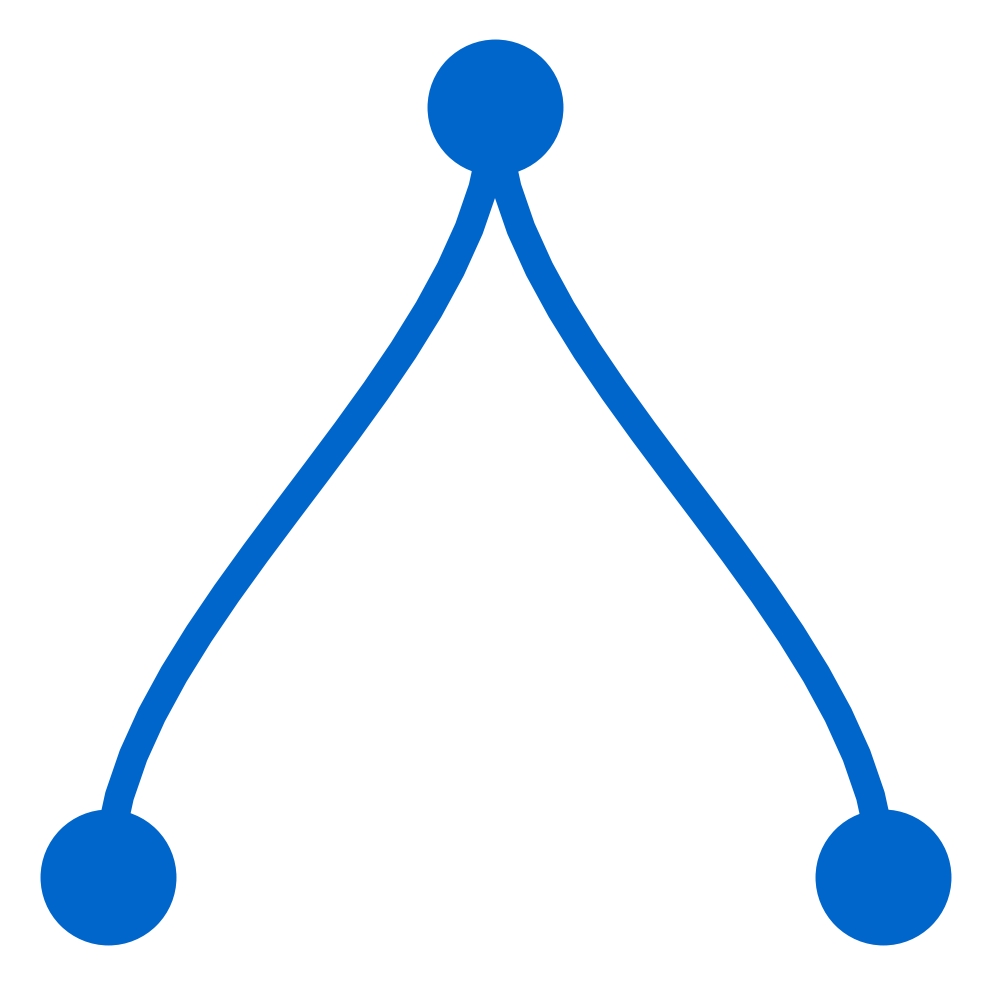

In [9]:
# Example: 2-to-1 neural network
weights = [[[0.7, 0.7]]]
biases = [[0.2]]
def custom_neuron_style(bias, value, vmax):
    style = default_neuron_style(bias, value, vmax)
    # style["col"] = [r, g, b]
    style["size"] = 1000.
    return style

def custom_connection_style(weight, y, vmax):
    style = default_connection_style(weight, y, vmax)
    style["linewidth"] = 7.0
    return style

fig, ax, posX, posY, y_all, z_all = visualize_network(
    weights=weights,
    biases=biases,
    activations=['sigmoid'],
    y_in = [1, 1], 
    xspacing=0.5, yspacing=0.5, 
    figsize=(4, 4), 
    neuron_kwargs={"stylefunc": custom_neuron_style}, 
    connection_kwargs={"stylefunc": custom_connection_style})


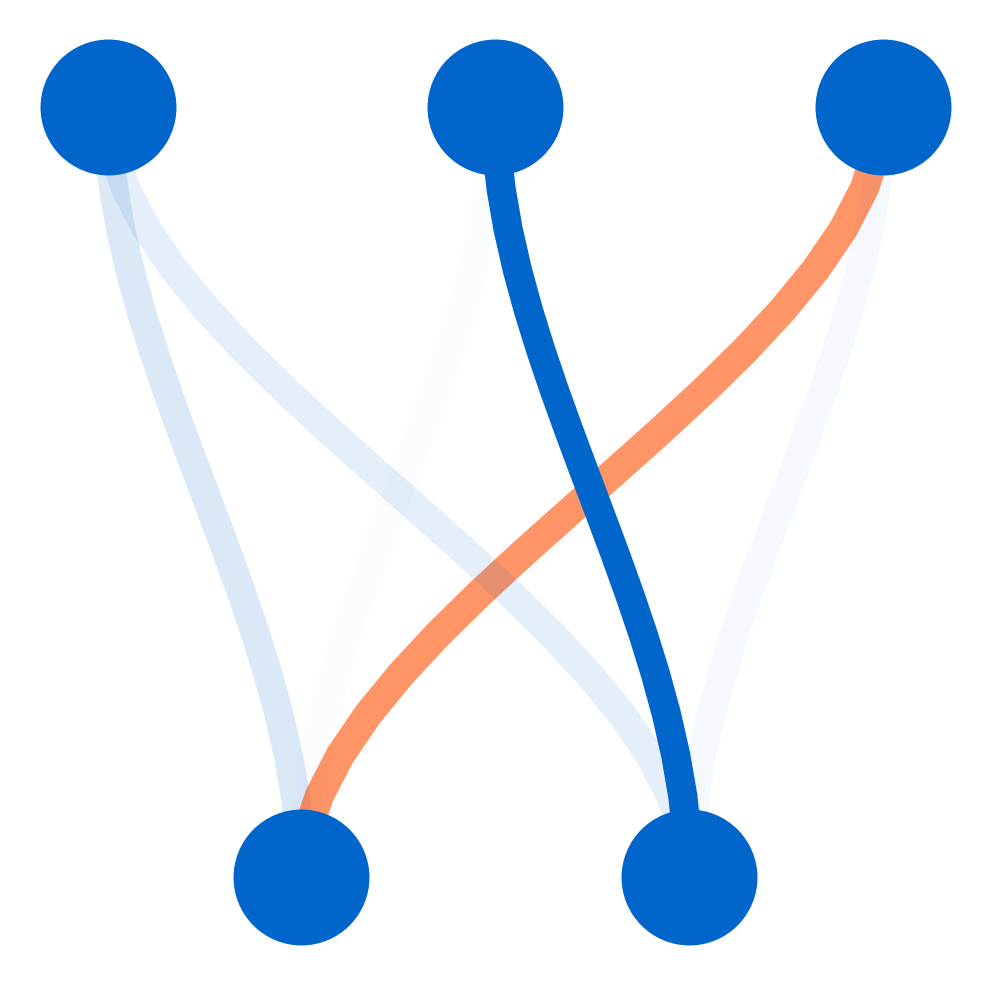

In [12]:
# Example: a small NN
weights = [[[0.7, 0.5], [0.1, 5.0], [-3.0, 0.2]]]
biases = [[0.2, 0.5, 0.1]]
def custom_neuron_style(bias, value, vmax):
    style = default_neuron_style(bias, value, vmax)
    # style["col"] = [r, g, b]
    style["size"] = 1000.
    return style

def custom_connection_style(weight, y, vmax):
    style = default_connection_style(weight, y, vmax)
    style["linewidth"] = 7.0
    return style

fig, ax, posX, posY, y_all, z_all = visualize_network(
    weights=weights,
    biases=biases,
    activations=['sigmoid'],
    y_in = [1, 1], 
    xspacing=0.5, yspacing=0.5, 
    figsize=(4, 4), 
    neuron_kwargs={"stylefunc": custom_neuron_style}, 
    connection_kwargs={"stylefunc": custom_connection_style})
fig.savefig("nn_2_to_3.svg")

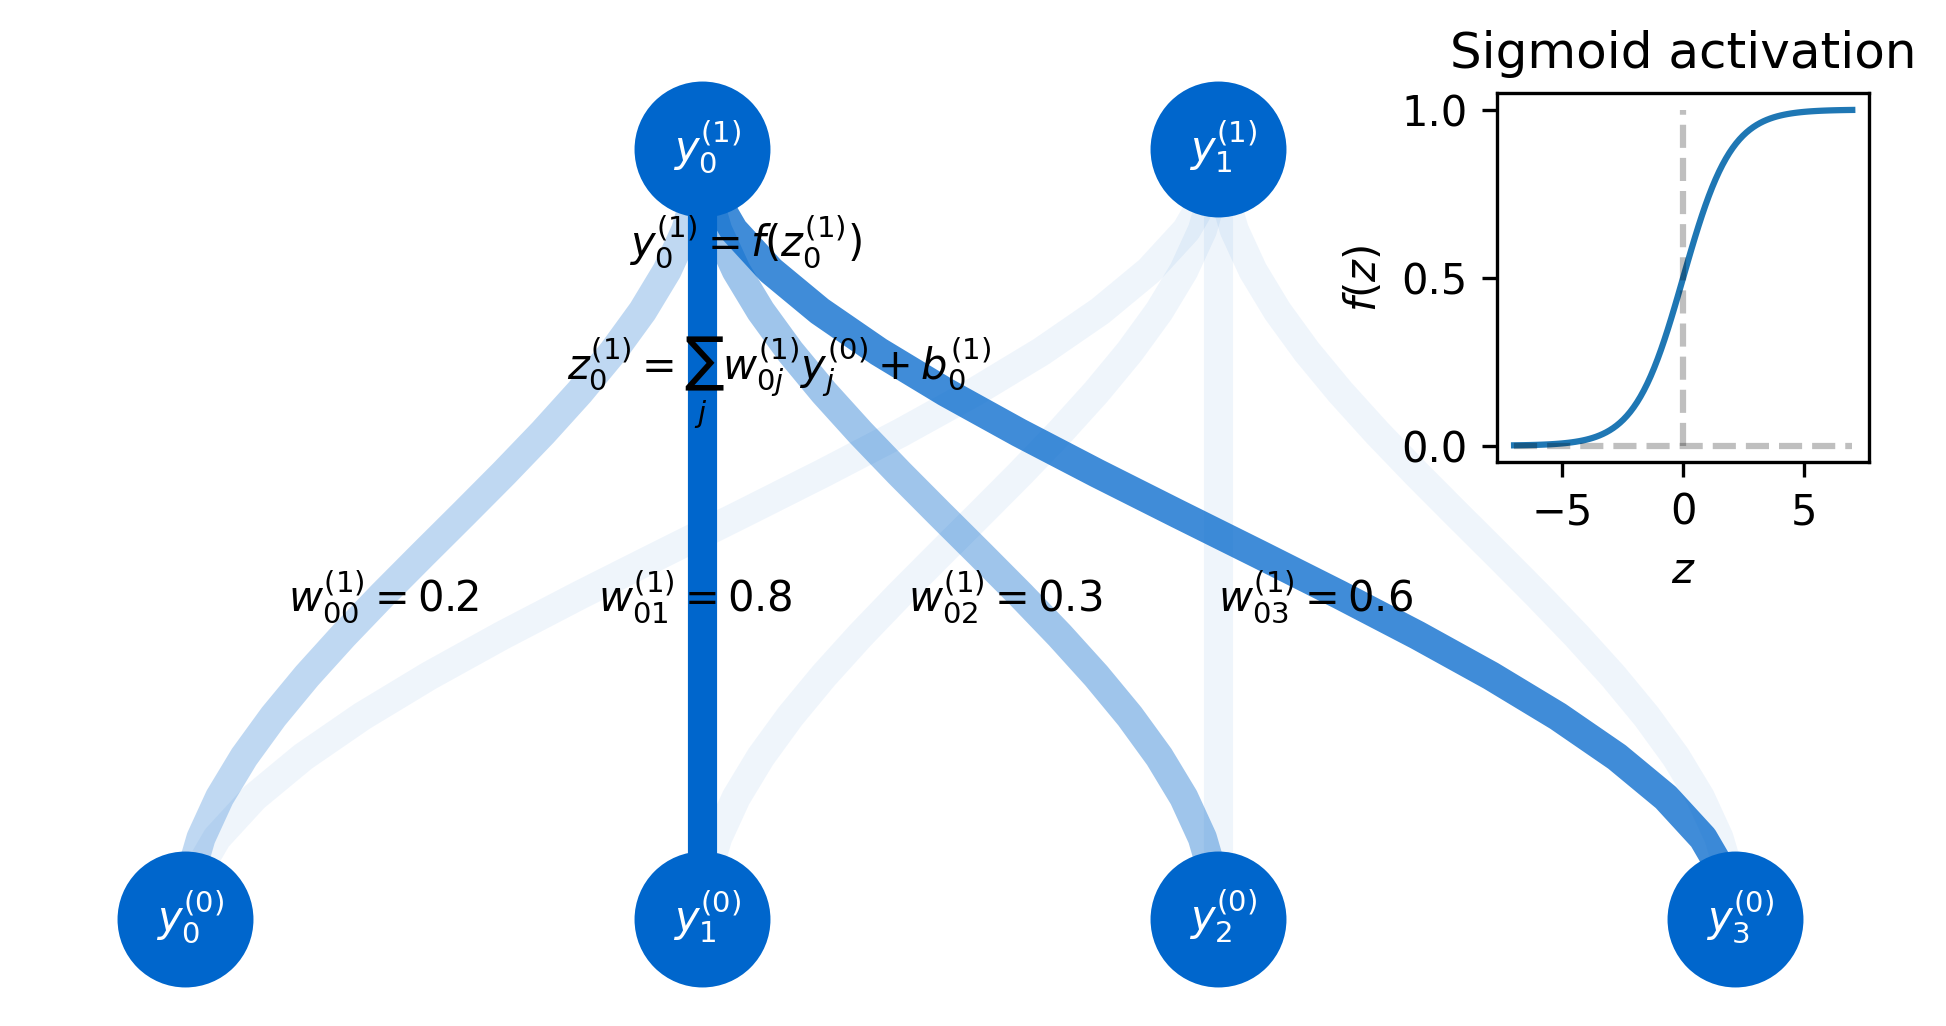

In [6]:
weights = [
            [[0.2, 0.8, 0.3, 0.6], [0.05, 0.05, 0.05, 0.05]]
            ]
biases = [[0.5, 0.01]]

def custom_neuron_style(bias, value, vmax):
    style = default_neuron_style(bias, value, vmax)
    style["size"] = 1000.
    return style

def custom_connection_style(weight, y, vmax):
    style = default_connection_style(weight, y, vmax)
    style["linewidth"] = 7.0
    return style
    
fig, ax, posX, posY, y_all, z_all = visualize_network(
    weights=weights,
    biases=biases,
    activations=['sigmoid'],
    y_in = [1, 1, 1, 1], 
    xspacing=0.5, yspacing=0.5, 
    figsize=(8, 4), 
    neuron_kwargs={"stylefunc": custom_neuron_style}, 
    connection_kwargs={"stylefunc": custom_connection_style})

# 1. Input neurons
for ilayer in range(len(posX)):
    for ineuron in range(len(posX[ilayer])):
        x = posX[ilayer][ineuron] - 0.028
        y = posY[ilayer][ineuron] - 0.008
        ax.text(x, y, rf"$y_{{{ineuron}}}^{{({ilayer})}}$", zorder=10, color="white")
fig.savefig("nn_singlelayer_1.svg")

# 2. z calculation
for ineuron in range(len(posX[0])):
    x_neuron = posX[0][ineuron]
    y_neuron = posY[0][ineuron]
    x_dest = posX[1][0]
    y_dest = posY[1][0]
    w = 0.6
    x = (w * x_neuron + (1-w) * x_dest) - 0.1
    y = w * y_neuron + (1-w) * y_dest
    ax.text(x, y, rf"$w_{{0{ineuron}}}^{{(1)}} = {weights[0][0][ineuron]}$")
#ax.text(posX[1][0]-0.07, posY[1][0] - 0.07, rf"$b_0^{{1}}={biases[0][0]}$", zorder=10)
ax.text(posX[1][0] - 0.13, posY[1][0] - 0.15, rf"$z^{{(1)}}_{{0}} = \sum_j w_{{0j}}^{{(1)}} y_{{j}}^{{(0)}} + b^{{(1)}}_{{0}}$")
fig.savefig("nn_singlelayer_2.svg")

# 3. activation function
ax.text(posX[1][0] - 0.07, posY[1][0] - 0.07, rf"$y^{{(1)}}_{{0}} = f(z^{{(1)}}_{{0}})$", zorder=10)
ax_ins = inset_axes(ax, width="20%", height="40%", loc="upper right")
x_act = np.linspace(-7, 7, 100)
y_act = 1. / (1. + np.exp(-x_act))
ax_ins.plot(x_act, y_act)
ax_ins.plot([-7, 7], [0, 0], ls="--", color=(0, 0, 0, 0.25))
ax_ins.plot([0, 0], [0, 1], ls="--", color=(0, 0, 0, 0.25))
ax_ins.set_xlabel("$z$")
ax_ins.set_ylabel("$f(z)$")
ax_ins.set_title("Sigmoid activation")
fig.savefig("nn_singlelayer_3.svg")

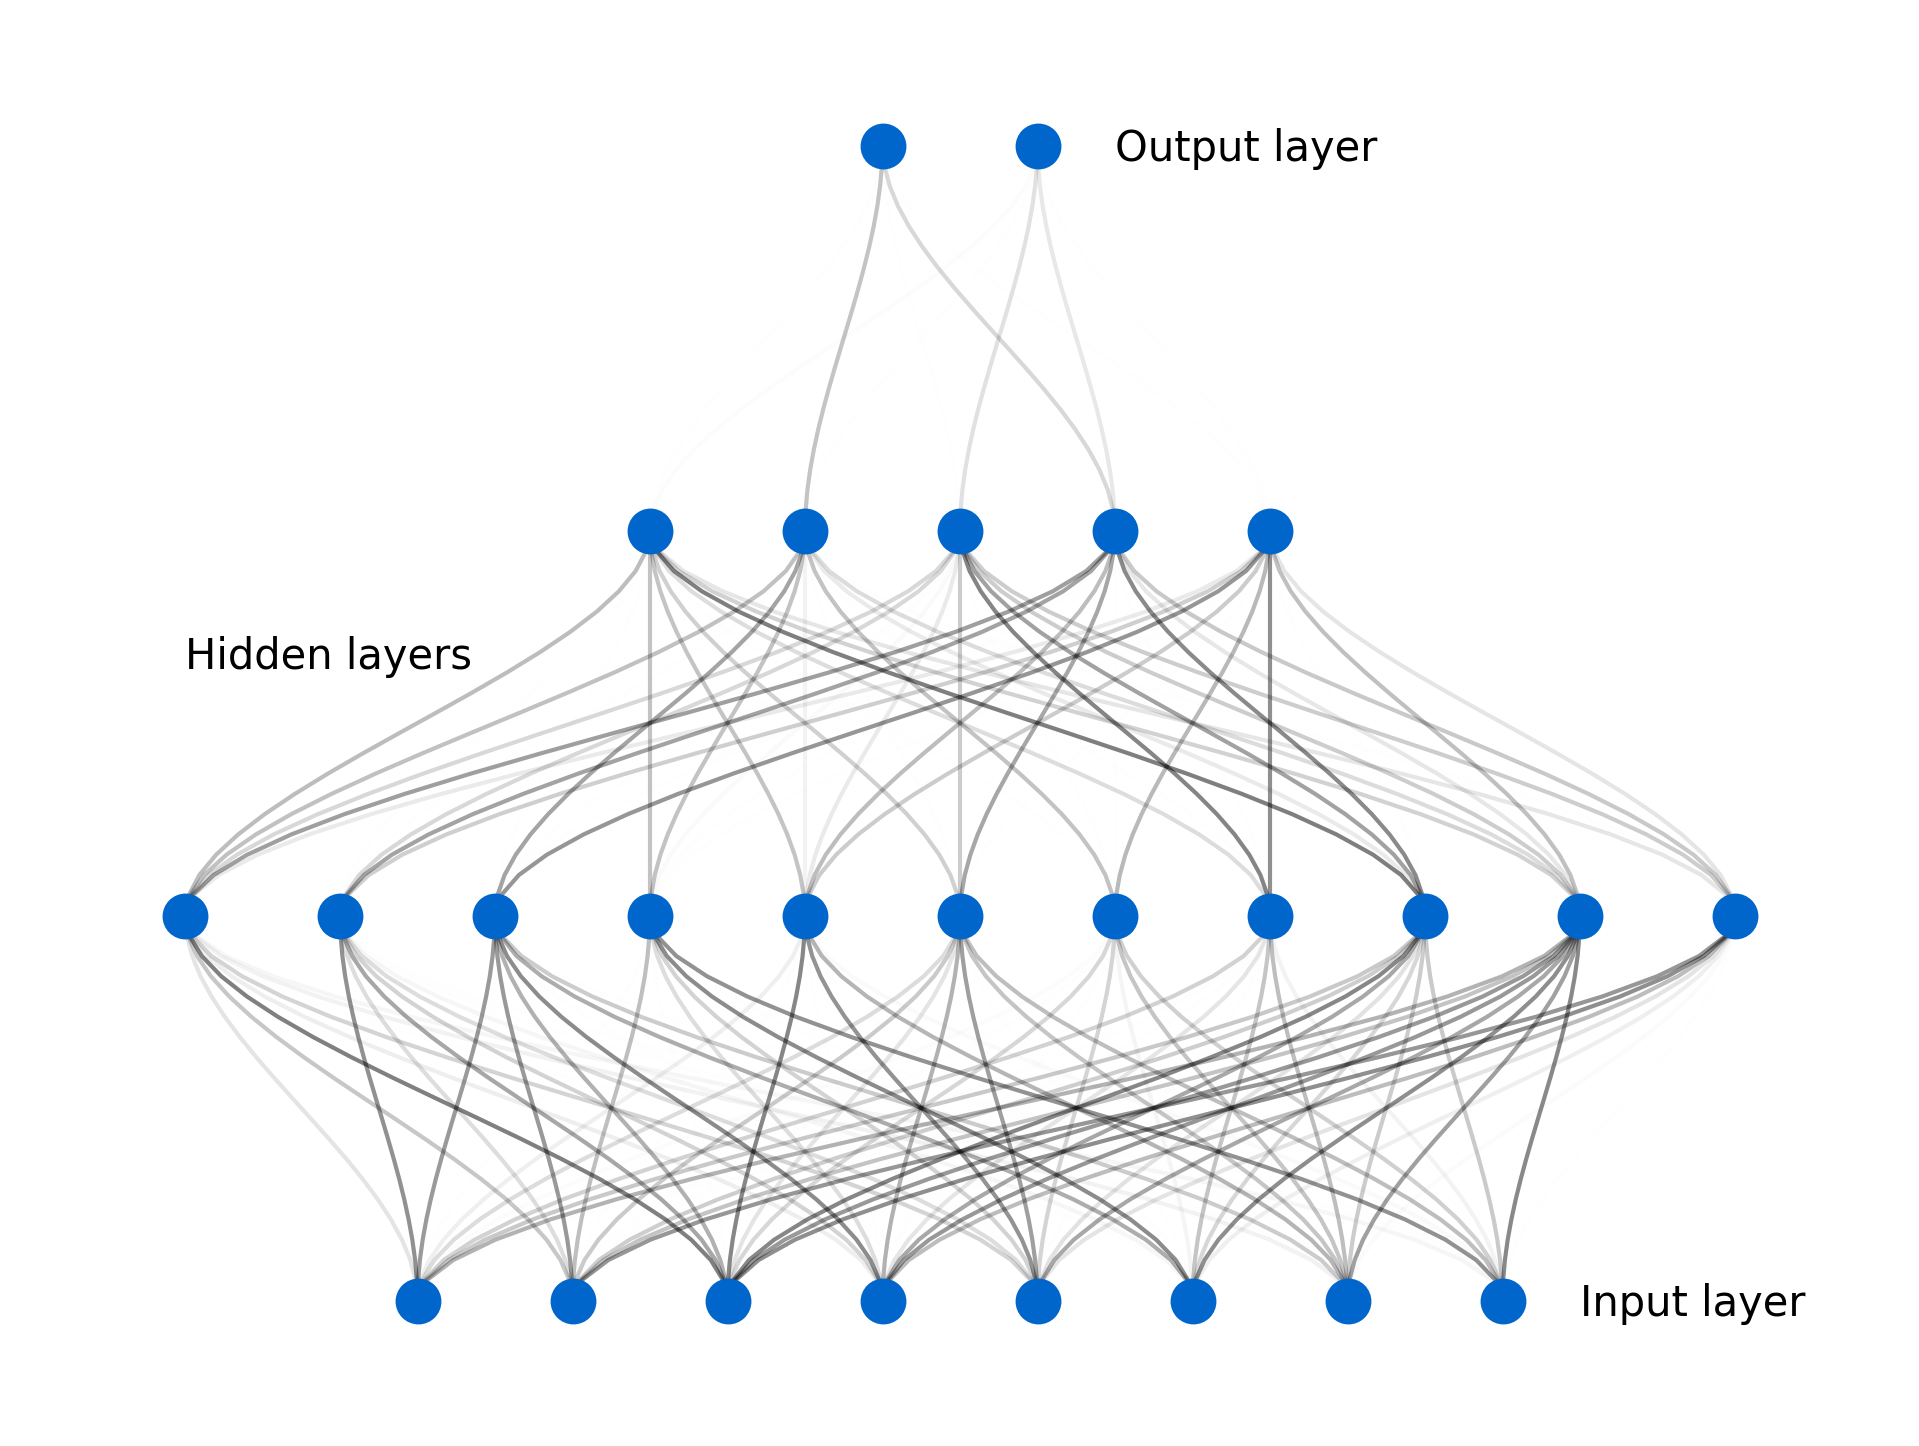

In [318]:
# Generate a large network with random weights
n_neurons = [8, 11, 5, 2]
#n_neurons = [4, 2]
weights = []
biases = []
activations = []
rng = np.random.default_rng()
max_weight = 0
for layer in range(1, len(n_neurons)):
    #this_weights = 1. / (1. + np.exp(-rng.standard_normal(size=(n_neurons[layer], n_neurons[layer-1]))))
    #this_weights = rng.binomial(100, 0.1, size=(n_neurons[layer], n_neurons[layer-1])) / 100.
    this_weights = rng.uniform(low=-1, high=1, size=(n_neurons[layer], n_neurons[layer-1]))
    this_weights = np.where(this_weights > -0.5, this_weights, 0.01)
    weights.append(this_weights)
    #print(weights[-1].shape)
    biases.append(np.random.rand(n_neurons[layer]))
    activations.append("sigmoid")
    #print(this_weights)
    max_weight = max(max_weight, np.max(this_weights))
y_in = np.random.rand(n_neurons[0])

def custom_connection_style(W, y, vmax):
    style = default_connection_style(W, y, vmax)
    style["col"] = [0, 0, 0, abs(W/vmax)]
    style["linewidth"] = 1
    return style
    
fig, ax, posX, posY, y_all, z_all = visualize_network(
    weights=weights,
    biases=biases,
    activations=activations,
    y_in=y_in, 
    xspacing=0.5, yspacing=0.5, 
    figsize=(8, 6), connection_kwargs={"stylefunc": custom_connection_style, "vmax": max_weight * 2}
    )
ax.text(2, -0.02, "Input layer")
ax.text(-2.5, 0.82, "Hidden layers")
ax.text(0.5, 1.48, "Output layer")
fig.savefig("nn_big.svg")

# 

[[], array([-0.04740197, -0.38306602, -0.32629735, -0.79685136,  0.82559878,
        0.60440594, -1.0460909 , -0.76157732,  1.16401145]), array([-1.13796514,  1.96102575])]


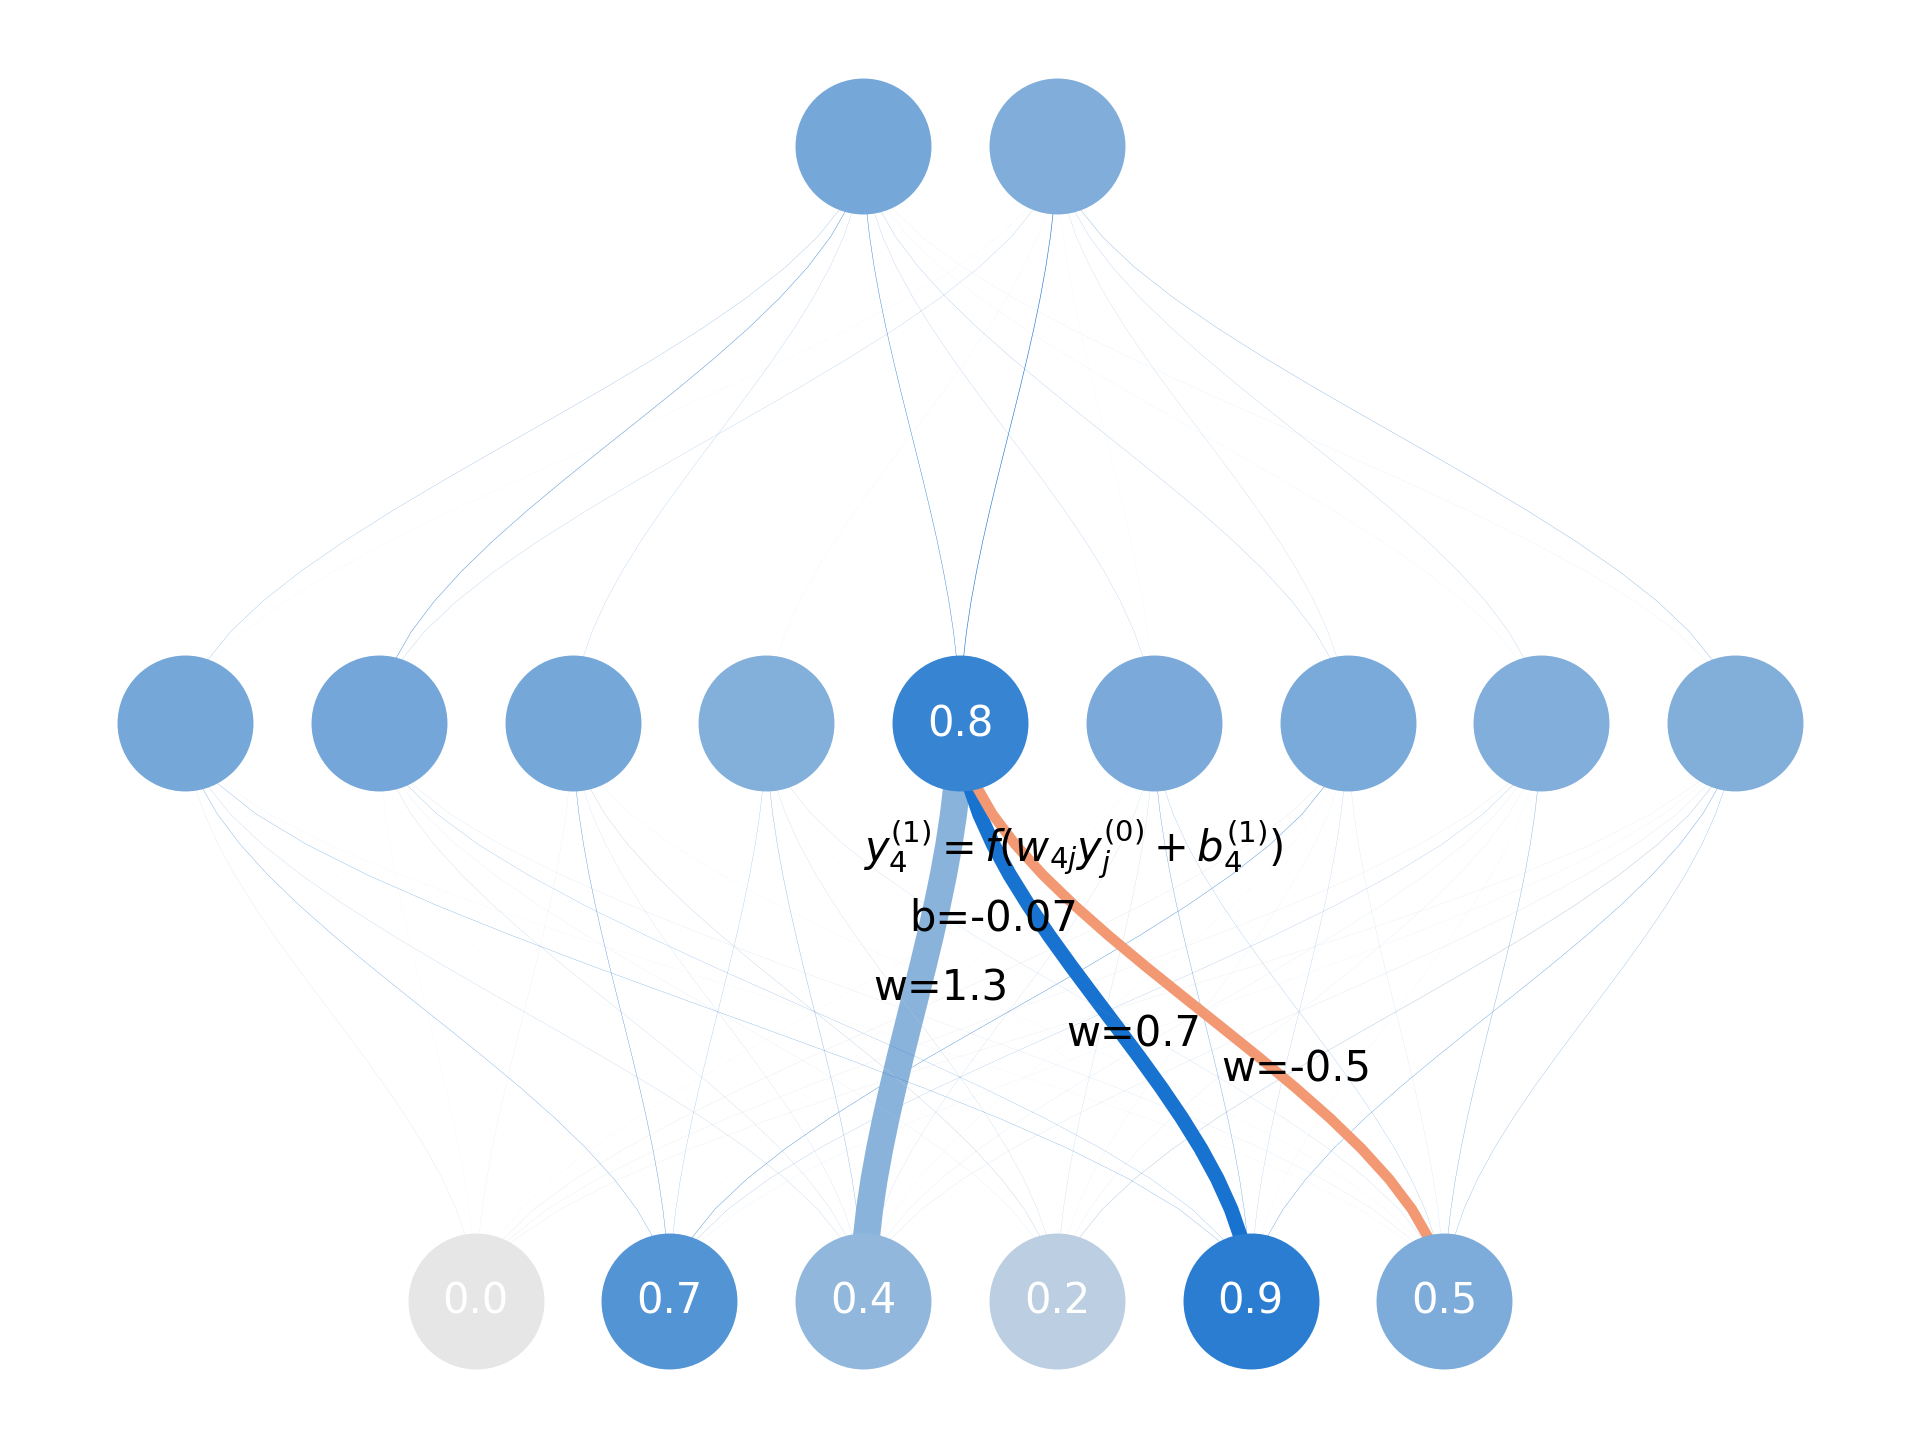

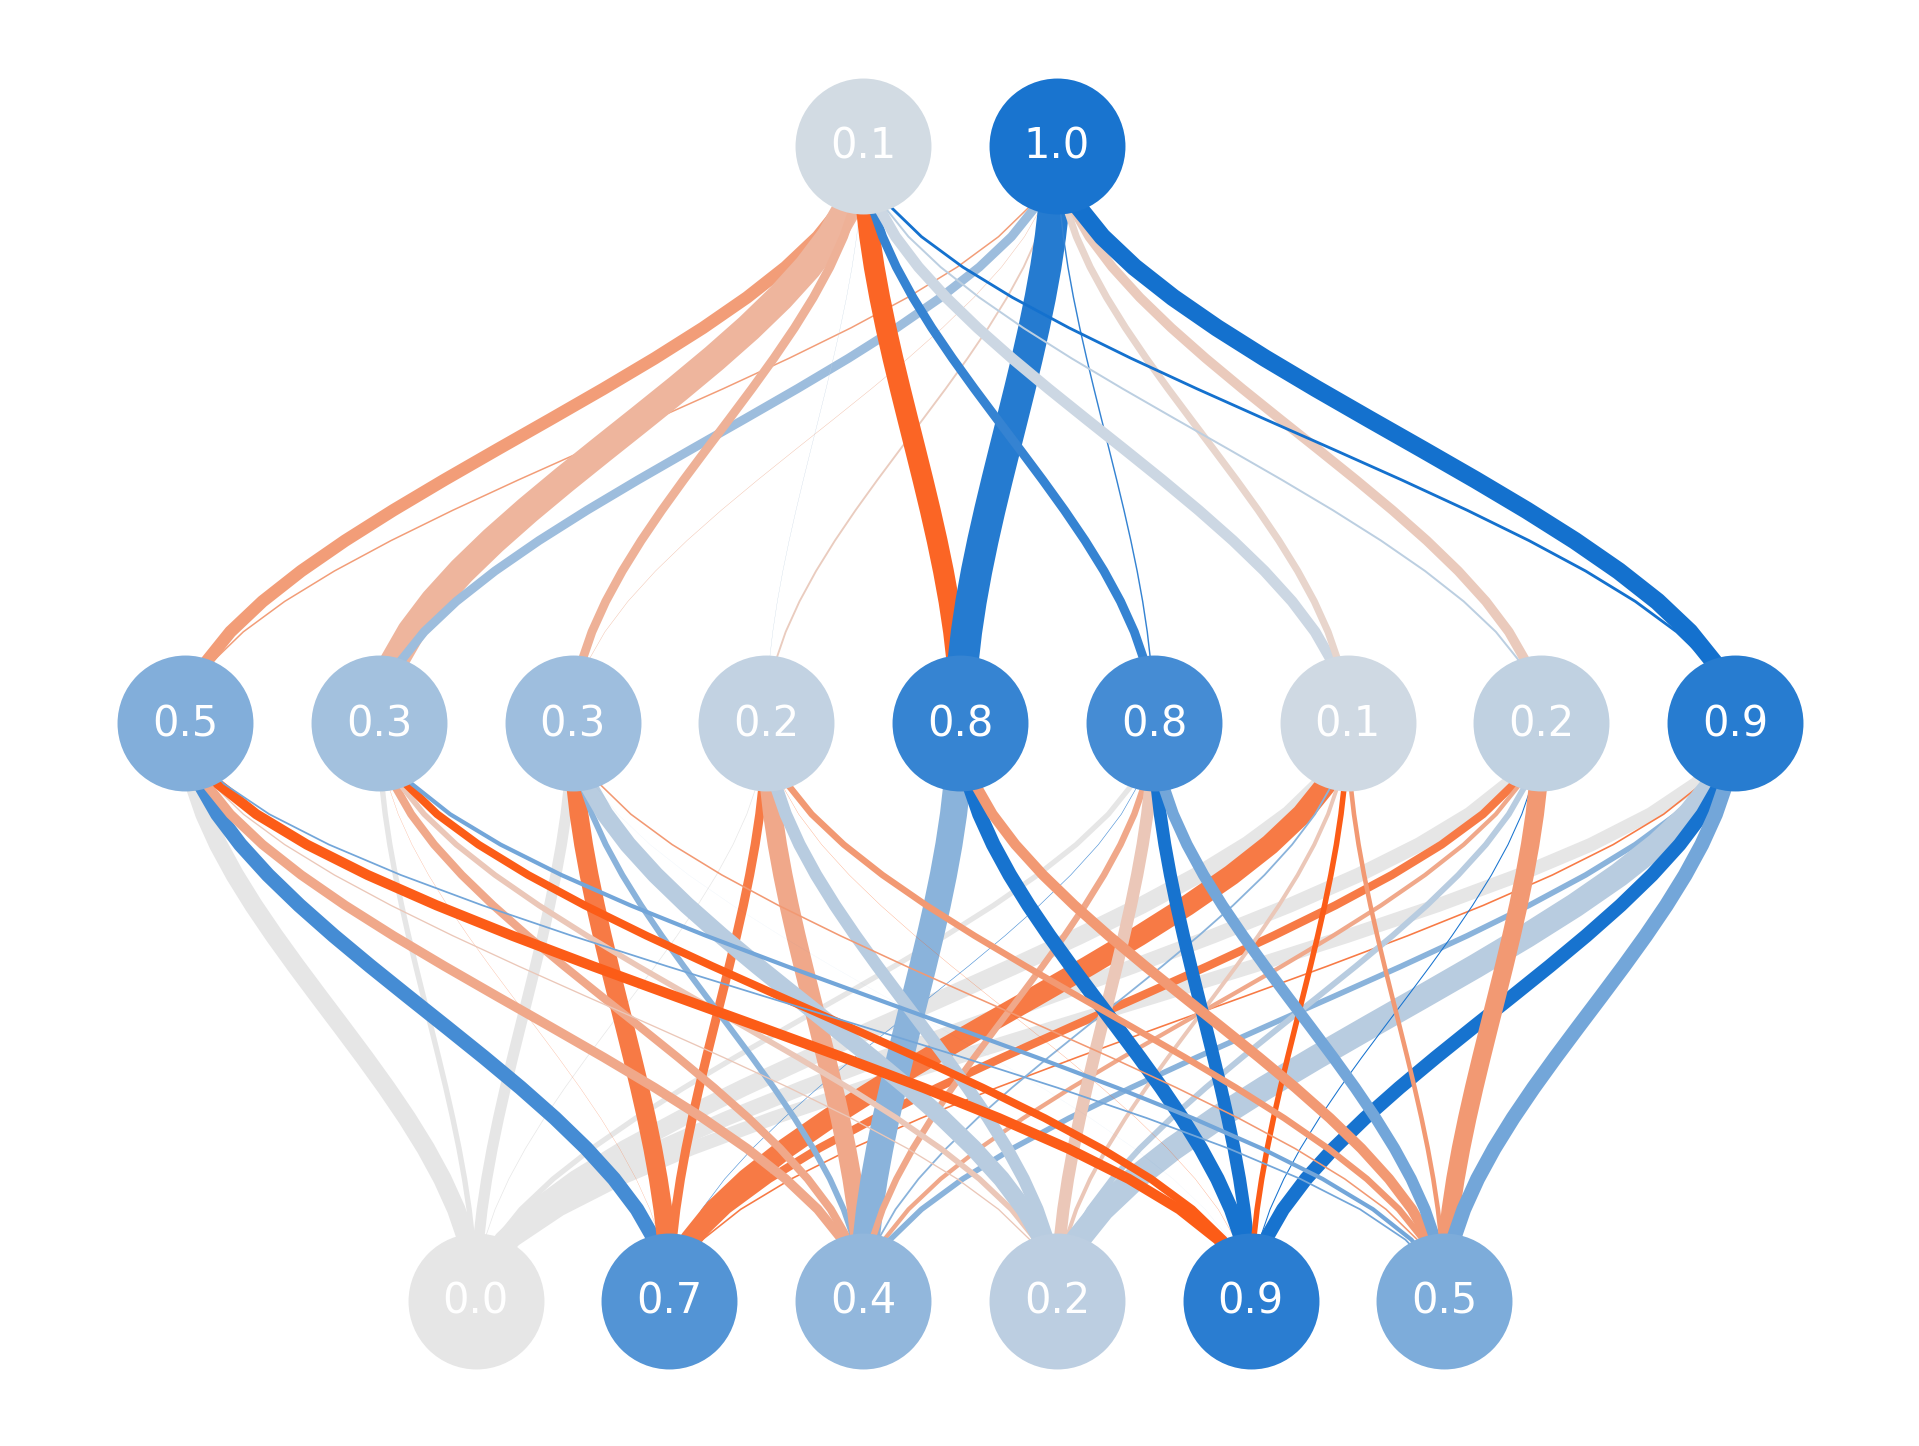

In [349]:
# Generate a large network with random weights
n_neurons = [6, 9, 2]
#n_neurons = [4, 2]
weights = []
biases = []
activations = []
rng = np.random.default_rng()
max_weight = 0
for layer in range(1, len(n_neurons)):
    #this_weights = 1. / (1. + np.exp(-rng.standard_normal(size=(n_neurons[layer], n_neurons[layer-1]))))
    #this_weights = rng.binomial(100, 0.1, size=(n_neurons[layer], n_neurons[layer-1])) / 100.
    this_weights = rng.normal(loc=0.0, scale=0.5, size=(n_neurons[layer], n_neurons[layer-1]))
    #this_weights = np.where(this_weights > -0.5, this_weights, 0.01)
    weights.append(this_weights)
    biases.append(rng.uniform(low=-0.1, high=0.1, size=(n_neurons[layer])))
    activations.append("sigmoid")
    max_weight = max(max_weight, np.max(this_weights))

# Set a few values by hand for beauty
weights[0][4, :] = np.array([0.0, 0.0, 1.3, 0.0, 0.7, -0.5])
weights[0][0, 1] = 0.7
weights[1][0, 0] = -0.6
weights[1][1, 4] = 1.5


# Make copy of weights and hide most
weights_plot = copy.deepcopy(weights)
for i in range(len(weights_plot)):
    weights_plot[i] = abs(weights_plot[i]) / 50
weights_plot[0][4, :] = np.array([0.0, 0.0, 1.3, 0.0, 0.7, -0.5])

y_in = np.array([0., 0.7, 0.4, 0.2, 0.9, 0.5])

def custom_neuron_style(bias, value, vmax):
    style = default_neuron_style(bias, value, vmax)
    style["size"] = 1000.
    w = abs(value) / 1.1
    style["col"] = w * np.array([0., 0.4, 0.8]) + (1-w) * np.array([0.9, 0.9, 0.9])
    return style
    
def custom_connection_style(W, y, vmax):
    style = default_connection_style(W, y, vmax)

    # Color: blue for large/positive w*y, fade to grey to low y, orange for large/negative w*y
    # y = [0, 1] for sigmoid
    w = abs(y)
    if W * y > 0:
        base = np.array([0., 0.4, 0.8])
    else:
        base = np.array([1., 0.3, 0.])
    style["col"] =  w * base + (1-w) * np.array([0.9, 0.9, 0.9])

    # Line width: proportional to the weight
    style["linewidth"] = 5 * W
    return style
        
fig, ax, posX, posY, y_all, z_all = visualize_network(
    weights=weights_plot,
    biases=biases,
    activations=activations,
    y_in=y_in, 
    xspacing=0.5, yspacing=0.5, 
    figsize=(8, 6), 
    neuron_kwargs={"stylefunc": custom_neuron_style},
    connection_kwargs={"stylefunc": custom_connection_style,  "vmax": max_weight * 2}
    )

# Draw inputs
for ineuron in range(len(posX[0])):
    x = posX[0][ineuron] - 0.085
    y = posY[0][ineuron] - 0.0115
    ax.text(x, y, f"{y_in[ineuron]}", zorder=10, color="white")
question_mark = ax.text(posX[1][4] - 0.025, posY[1][4] - 0.0115, "?", zorder=10, color="white")
fig.savefig("nn_ff_1.svg")

# Draw some weights
question_mark.remove()
tboxes = []
terms = []
dx = [0, 0, -0.1, 0, -0.1, 0.05]
dy = [0, 0, 0.01, 0, -0.03, -0.06]
for ineuron in range(len(posX[0])):
    xdest = posX[1][4]
    ydest = posY[1][4]
    if weights_plot[0][4, ineuron] != 0:
        tboxes.append(ax.text(0.5 * (posX[0][ineuron] + xdest) + dx[ineuron], 0.5 * (posY[0][ineuron] + ydest) + dy[ineuron], f"w={weights_plot[0][4, ineuron]}"))
        terms.append(f"{weights_plot[0][4, ineuron]}*{y_in[ineuron]}")
tboxes.append(ax.text(posX[1][4]-0.085, posY[1][4]-0.0115, f"{y_all[1][4]:.1f}", zorder=10, color="white"))
tboxes.append(ax.text(posX[1][4]-0.13, posY[1][4]-0.18, f"b={biases[0][4]:.2f}", zorder=10))
tboxes.append(ax.text(posX[1][4]-0.25, posY[1][4]-0.12, rf"$y_4^{{(1)}}=f(w_{{4j}}y_j^{{(0)}}+b_4^{{(1)}})$", zorder=10))
fig.savefig("nn_ff_2.svg")

# Now the whole network. 
weights_plot = copy.deepcopy(weights)
#weights[0][4, :] = np.array([0.0, 0.0, 1.3, 0.0, 0.7, -0.5])
fig, ax, posX, posY, y_all, z_all = visualize_network(
    weights=weights_plot,
    biases=biases,
    activations=activations,
    y_in=y_in, 
    xspacing=0.5, yspacing=0.5, 
    figsize=(8, 6), 
    neuron_kwargs={"stylefunc": custom_neuron_style},
    connection_kwargs={"stylefunc": custom_connection_style, "vmax": max_weight * 2}
    )
print(z_all)

# First, plot all y values in first hidden layer
for ilayer in [0, 1]:
    for ineuron in range(len(posX[ilayer])):
        ax.text(posX[ilayer][ineuron]-0.085, posY[ilayer][ineuron]-0.0115, f"{y_all[ilayer][ineuron]:.1f}", zorder=10, color="white")
fig.savefig("nn_ff_3.svg")

# Then all y values
for ilayer in [2]:
    for ineuron in range(len(posX[ilayer])):
        ax.text(posX[ilayer][ineuron]-0.085, posY[ilayer][ineuron]-0.0115, f"{y_all[ilayer][ineuron]:.1f}", zorder=10, color="white")
fig.savefig("nn_ff_4.svg")

